In [1]:
import pydmr
import dcmri as dc

data_file = dc.fetch('tristan_humans_healthy_rifampicin')
data = pydmr.read(data_file, 'nest')
rois = data['rois']
subjects = list(rois.keys())

In [2]:
from challenge_spiro.utils.score import parse_data

subj_idx, visit_idx = 0, 0

subject = subjects[subj_idx]
visits = list(rois[subject].keys())
visit = visits[visit_idx]
time, signal, settings = parse_data(data_file, subject, visit)

In [3]:
import numpy as np

def print_recon_err(signal_recon, signal):
    err = []
    for i in range(4):
        err_i = np.linalg.norm(signal_recon[i] - signal[i]) / np.linalg.norm(signal[i])
        err.append(err_i)
    err = max(err)
    print(f"Reconstruction error: {100 * err} %")

In [4]:
from challenge_spiro.solutions.submitted.muzammil import inverse
from challenge_spiro.utils.model import forward

params_recon_submission = inverse(time, signal, **settings)
signal_recon_submission = forward(params_recon_submission, time, **settings)

print_recon_err(signal_recon_submission, signal)

Reconstruction error: 75.45347731543332 %


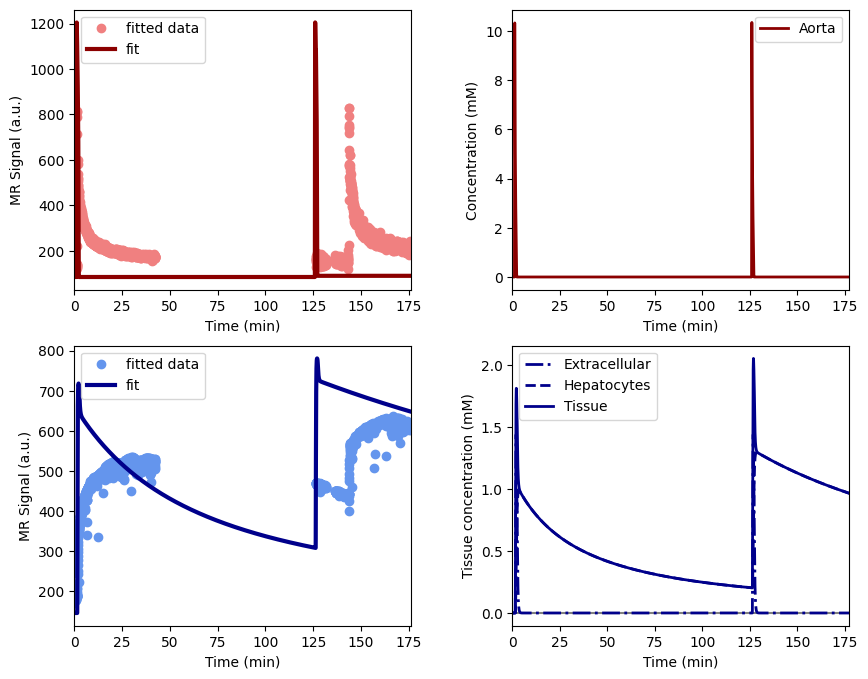

In [5]:
from challenge_spiro.utils.model import plot

plot(params_recon_submission, time, signal, **settings)

In [6]:
from challenge_spiro.solutions.provided.benchmark import inverse
from challenge_spiro.utils.model import forward

params_recon_benchmark = inverse(time, signal, **settings)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.6285e+07                                    3.34e+09    
       1              2         4.8922e+06      2.14e+07       1.15e+03       2.39e+09    
       2              3         2.1635e+06      2.73e+06       3.23e+02       1.01e+09    
       3              4         1.2640e+06      8.99e+05       1.98e+02       9.90e+08    
       4              5         5.7530e+05      6.89e+05       1.24e+02       1.09e+09    
       5              6         3.2145e+05      2.54e+05       7.58e+01       6.92e+08    
       6              7         2.3266e+05      8.88e+04       3.73e+01       3.66e+08    
       7              8         2.0660e+05      2.61e+04       1.76e+01       4.91e+07    
       8              9         1.9994e+05      6.66e+03       2.27e+01       1.09e+05    
       9             10         1.9914e+05      7.94e+02       1.38e+01       2.24e+06    

In [7]:
signal_recon_benchmark = forward(params_recon_benchmark, time, **settings)

print_recon_err(signal_recon_benchmark, signal)

Reconstruction error: 5.735734910178174 %


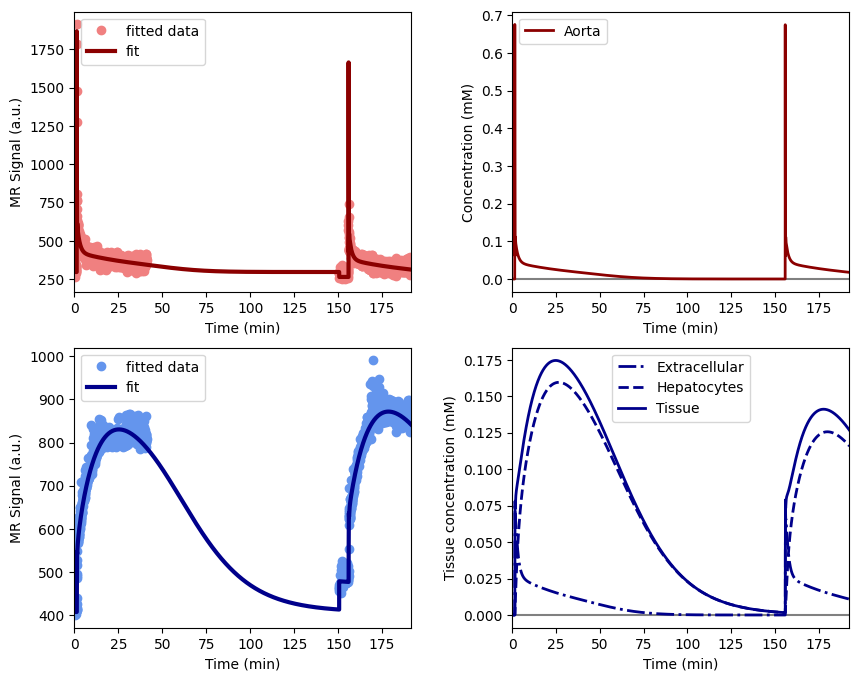

In [ ]:
plot(params_recon_benchmark, time, signal, **settings)